In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
# checking the null value
df.isnull().sum()

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [11]:
# drop the unused columns 
df.drop(columns=['year','month','Unnamed: 0'],axis=1,inplace=True)

In [12]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


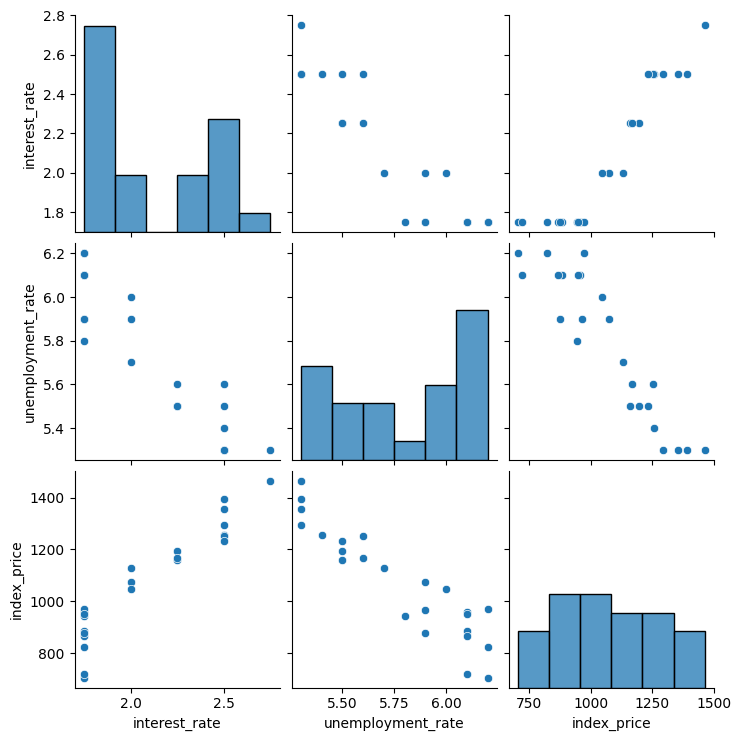

In [16]:
# visualize

sns.pairplot(df)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

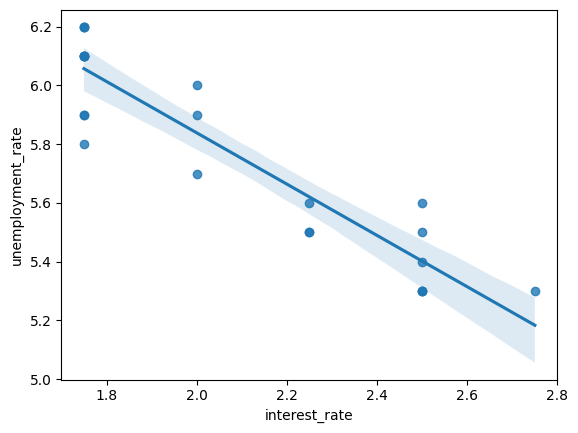

In [25]:
## regression line of the interest_rate and unemployment_rate 

sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'],data=df)


<Axes: xlabel='interest_rate', ylabel='index_price'>

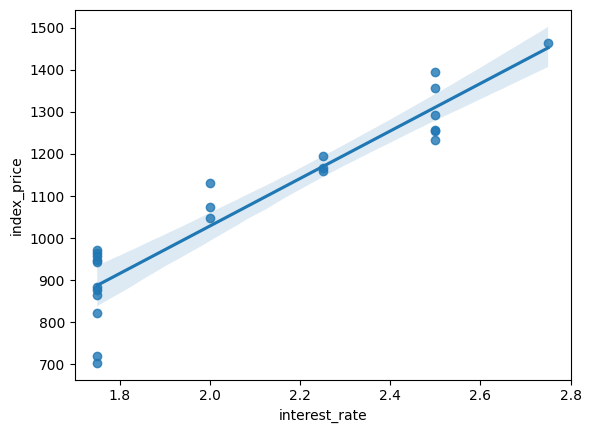

In [26]:
sns.regplot(x=df['interest_rate'],y=df['index_price'],data=df)

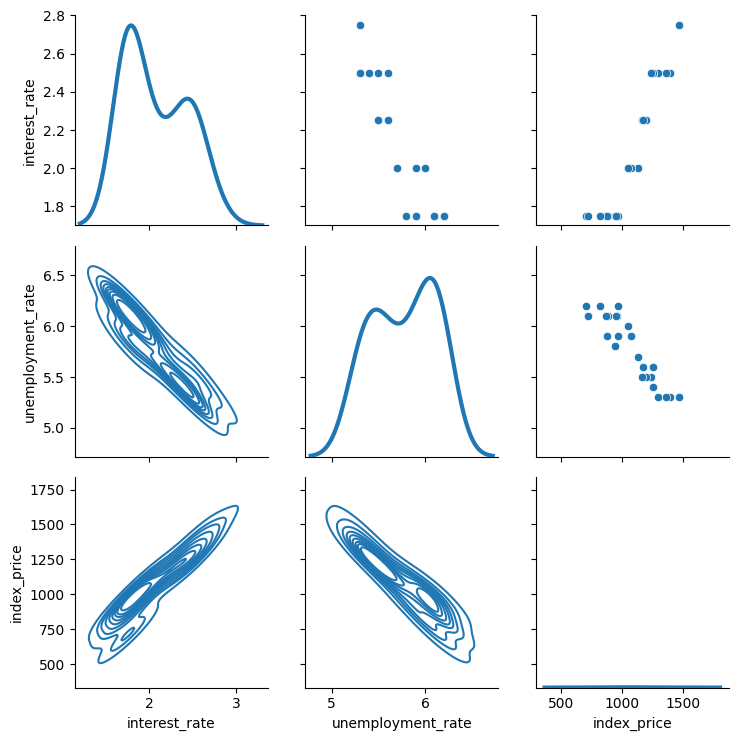

In [27]:
g = sns.PairGrid(df)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

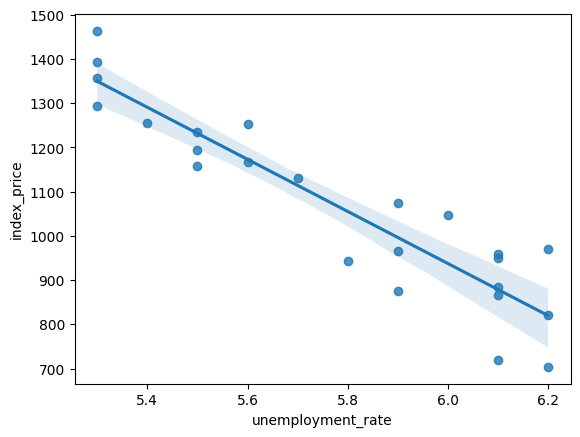

In [28]:
sns.regplot(x=df['unemployment_rate'],y=df['index_price'],data=df)

In [38]:
# correlation 
d=df.corr()

<Axes: >

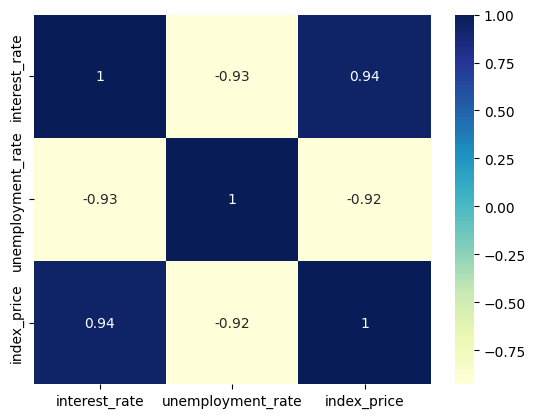

In [39]:
sns.heatmap(data=d,annot=True,cmap="YlGnBu")

In [40]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [50]:
# seperate the dependent and independent variable
x=df[['unemployment_rate','interest_rate']]
y=df['index_price']


In [14]:
## split the train test split data
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
std=StandardScaler()

In [59]:
x_train=std.fit_transform(x_train)
x_test=std.fit_transform(x_test)

In [64]:
from sklearn.linear_model import LinearRegression

In [65]:
model=LinearRegression()

In [67]:
m1=model.fit(x_train,y_train)

In [72]:
m1.score(x_test,y_test)

0.6848174339176984

In [75]:
## Cross validation 
from sklearn.model_selection import cross_validate

In [76]:
cv_result=cross_validate(m1,x_train,y_train,cv=3)

In [80]:
sorted(cv_result.keys())

['fit_time', 'score_time', 'test_score']

In [82]:
np.mean(cv_result['test_score'])

np.float64(0.7612368464755527)

In [83]:
y_pred=m1.predict(x_test)

In [84]:
y_pred

array([1141.63549621,  787.98167849, 1339.94389614,  819.05076205,
        949.27404557, 1110.56641265,  881.18892917, 1271.85877973])

In [86]:
## Performance matrix 

from sklearn.metrics import mean_absolute_error,mean_squared_error


In [87]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)

print(rmse)

11792.511387420955
97.18749999999999
108.59333030817756


In [91]:
## r-square and adjusted r-square 
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

# Display adjusted r-squared
print(1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))


0.6848174339176984
0.5587444074847778


## Assumptions 


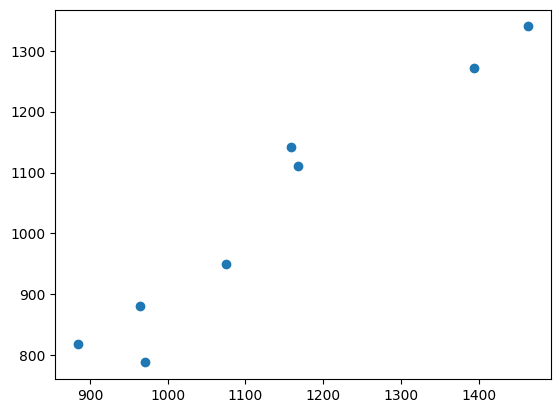

In [92]:
plt.scatter(y_test,y_pred)

In [93]:
residuals=y_test-y_pred
print(residuals)

8      17.364504
16    183.018322
0     124.056104
18     64.949238
11    125.725954
9      56.433587
13     83.811071
1     122.141220
Name: index_price, dtype: float64


C:\Users\Madhav Yadav\AppData\Local\Temp\ipykernel_8136\3762910054.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='index_price', ylabel='Density'>

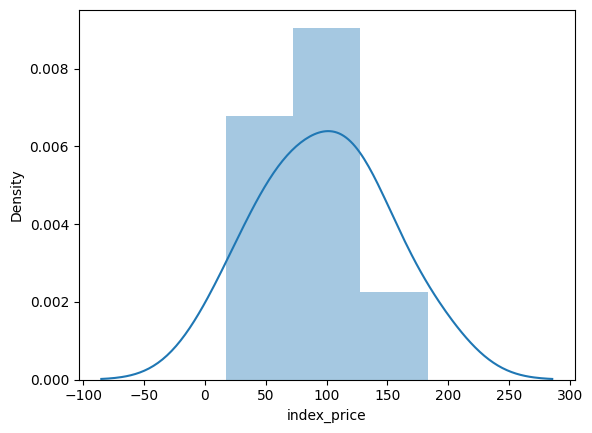

In [95]:
sns.distplot(residuals,kde=True)

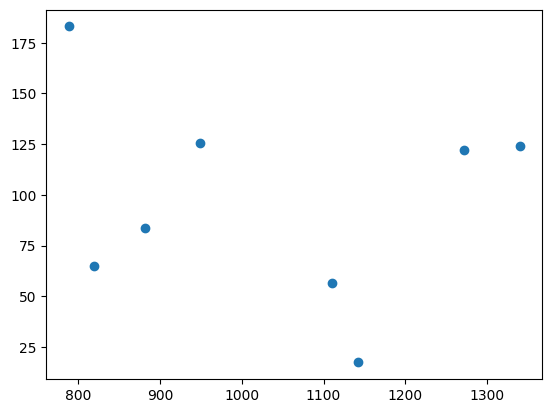

In [97]:
## Scatter plot with respect to prediction and residuals 
plt.scatter(y_pred,residuals)

In [98]:
import statsmodels.api as sm

In [99]:
models=sm.OLS(y_train,x_train).fit()

In [101]:
models.summary()

C:\Users\Madhav Yadav\myenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.105
Method:                 Least Squares   F-statistic:                             0.2425
Date:                Sun, 09 Nov 2025   Prob (F-statistic):                       0.788
Time:                        08:49:55   Log-Likelihood:                         -133.85
No. Observations:                  16   AIC:                                      271.7
Df Residuals:                      14   BIC:                                      273.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -101.5702    682.952     -0.149      0.884   -1566.357    1363.216
x2            96.2869    682.952      0.141      0.890   -1368.500    1561.074
==============================================================================
Omnibus:                        0.466   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.792   Jarque-Bera (JB):                0.412
Skew:                          -0.327   Prob(JB):                        0.814
Kurtosis:                       2.563   Cond. No.                         4.70
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""